In [33]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,roc_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# 1. Load Clean Data

In [2]:
df_raw = pd.read_csv('clean_data.csv')
df = df_raw.copy()

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


# 2. Data Preprocessing

In this phase I use LabelEncoder to labeling `object` columns.

In [4]:
df = df.drop(columns='customerID')

In [5]:
label = LabelEncoder()

In [6]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = label.fit_transform(df[col])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


# 3. Split Data

In this phase, I will split the data into training and test sets. Since our target variable (Churn) is highly imbalanced (Class 0: 5174, Class 1: 1869), I am using stratify=y for the initial split and StratifiedKFold for cross-validation. This ensures that the proportion of churned to retained customers remains consistent across all folds.

Additionally, I decided to drop the TotalCharges column due to its strong multicollinearity with tenure (Pearson's r = 0.83).

In [8]:
y = df['Churn']
X = df.drop(columns=['Churn','TotalCharges'])
kfold = StratifiedKFold(n_splits=5, random_state=7, shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=7
)

# 4. Results Functions

I developed Python functions to show confusion matrix, models metrics and feature importance.

In [9]:
def show_matrix(cm):
        plt.figure(figsize=(5,5))
        sns.heatmap(cm, cmap='inferno', annot=True, fmt='.2f', square=True, cbar=False, xticklabels=['Stay','Churn'], yticklabels=['Stay','Churn'])
        plt.show()
def show_results(cm):
        TN = cm[0,0]
        FP = cm[0,1]
        FN = cm[1,0]
        TP = cm[1,1]
        Precision = TP / (TP + FP)
        Recall = TP / (TP + FN)
        Specificity = TN / (TN + FP)
        Accuracy = (TP + TN) / (TP + TN + FP + FN)
        F1  = (2 * Precision * Recall) / (Precision + Recall)                
        results = print(f"""
        Precision: {Precision}
        Recall: {Recall}
        Specificity: {Specificity}
        Accuracy: {Accuracy}
        F1 Score: {F1}
        """)
def feature_importance(model, feature_names, title, top_n=15):
    estimator = model.named_steps.get('rf') or model.named_steps.get('xgb')
    importances = estimator.feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=True).tail(top_n)
    plt.figure(figsize=(8,6))
    fi.plot(kind='barh')
    plt.title(f'Feature Importance - {title}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

def coefficients(model, feature_names, top_n=15):
    coefs = model.named_steps['log_reg'].coef_[0]
    fi = pd.Series(coefs, index=feature_names)
    fi = fi.abs().sort_values(ascending=True).tail(top_n)
    plt.figure(figsize=(8,6))
    fi.plot(kind='barh')
    plt.title('Feature Importance - Logistic Regression Tuned')
    plt.xlabel('Absolute coefficient value')
    plt.tight_layout()
    plt.show()
                   
    
    

# 4. Logistic Regression (Baseline Model)

# 4.1 First Model (Default settings)

In [10]:
model_log = make_pipeline(StandardScaler(), LogisticRegression())
model_log.fit(X_train, y_train)
y_pred_log = model_log.predict(X_test)
cm_log = confusion_matrix(y_test, y_pred_log)

### 4.1.1 Model Results

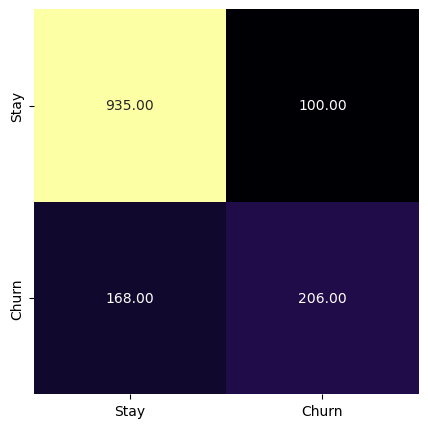


        Precision: 0.673202614379085
        Recall: 0.5508021390374331
        Specificity: 0.9033816425120773
        Accuracy: 0.8097941802696949
        F1 Score: 0.6058823529411765
        


In [11]:
show_matrix(cm_log)
show_results(cm_log)

**Insights:**
1. **Business Impact (Confusion Matrix for Churn):**
    * **Caught Churners (True Positive):** The model successfully identified 206 customers who actually churned.
    * **Missed Churners (False Negative):** The model failed to identify 168 customers who churned.
    * **False Alarms (False Positive):** The model incorrectly flagged 100 loyal customers as churners. This is the potential cost of unnecessary discounts.
2. **Key Churn Metrics:**
   * **Recall:** Out of all actual churners model successfully detected 55.08%
   * **Precision:** When the model rings the alarm and predicts a churn, it is correct 67.32% of the time.
   * **F1 Score:** The overall effectiveness of this model at handling the minority Churn class is 60.58%.

## 4.2 Handling Class Imbalance (F1-Score Optimization)

Since the dataset is highly imbalanced, accuracy as a default scoring metric would be misleading. F1 score better captures the trade-off between Precision and Recall for the minority Churn class.

In [12]:
pipe_log_f = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=1000, random_state=7))
])
param_grid_log_f = {
    'log_reg__C': [0.001, 0.01, 0.1, 1, 10],
    'log_reg__penalty': ['l1','l2'],
    'log_reg__solver': ['liblinear'],
    'log_reg__class_weight': ['balanced', None]
}
grid_search_log_f = GridSearchCV(estimator=pipe_log_f,
                           param_grid = param_grid_log_f,
                           cv=kfold,
                           scoring='f1',
                           n_jobs=-1,
                           verbose=1)
grid_search_log_f.fit(X_train, y_train)
print('The best parameters:', grid_search_log_f.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
The best parameters: {'log_reg__C': 0.1, 'log_reg__class_weight': 'balanced', 'log_reg__penalty': 'l2', 'log_reg__solver': 'liblinear'}


In [13]:
best_model_log_f = grid_search_log_f.best_estimator_
y_pred_log_f = best_model_log_f.predict(X_test)
y_prob_log_f = best_model_log_f.predict_proba(X_test)[:,1]
roc_auc_log_f = roc_auc_score(y_test, y_prob_log_f)
cm_log_f = confusion_matrix(y_test, y_pred_log_f)

### 4.2.1 Model Results

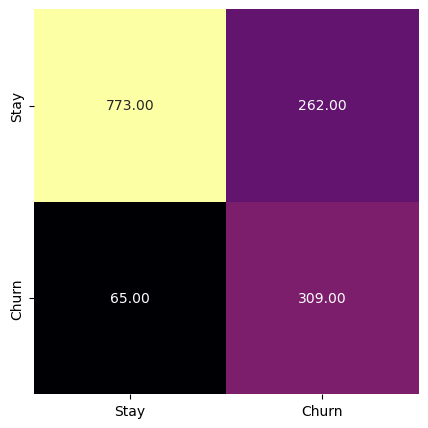


        Precision: 0.5411558669001751
        Recall: 0.8262032085561497
        Specificity: 0.7468599033816425
        Accuracy: 0.7679205110007097
        F1 Score: 0.653968253968254
        
ROC-AUC: 0.8542612829057843


In [14]:
show_matrix(cm_log_f)
show_results(cm_log_f)
print(f"ROC-AUC: {roc_auc_log_f}")

**Insights:**
1. **Business Impact (Confusion Matrix for Churn):**
    * **Caught Churners (True Positive):** The model successfully identified 309 customers who actually churned.
    * **Missed Churners (False Negative):** The model failed to identify 65 customers who churned.
    * **False Alarms (False Positive):** The model incorrectly flagged 262 loyal customers as churners. This is the potential cost of unnecessary discounts.
2. **Key Churn Metrics:**
   * **Recall:** Out of all actual churners model successfully detected 82.26%
   * **Precision:** When the model rings the alarm and predicts a churn, it is correct 54.12% of the time.
   * **F1 Score:** The overall effectiveness of this model at handling the minority Churn class is 65.39%.
   * **ROC-AUC:** The model's ability to distinguish between churners and loyal customers is 85.43%, indicating a very good discriminative performance.

**Conclusion:**

This optimized model significantly improved Recall compared to baseline (55.08% vs 82.26%), dropping the number of missed churners from 168 to just 65. The drop in Precision is an expected consequence of `class_weight='balanced'`, which intentionally penalizes missed churners more heavily. Given that the cost of losing a customer typically exceeds the cost of an unnecessary discount, this trade-off is acceptable.

### 4.2.2 Feature Importance

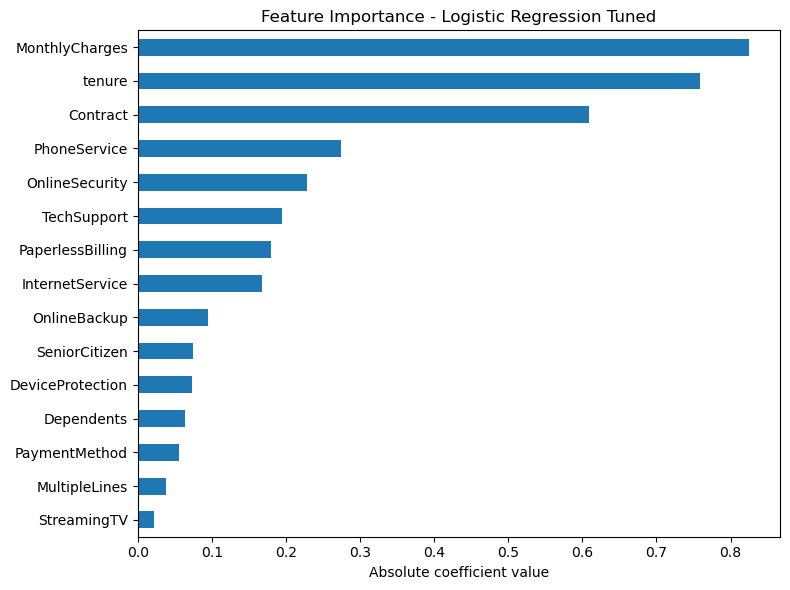

In [15]:
coefficients(best_model_log_f, X_train.columns)

**Insights:**

The three most influential features are MonthlyCharges (~ 0.82), tenure (~ 0.78) and Contract (~ 0.61).

# 5. Random Forest Classifier

## 5.1 First Model (Default settings)

In [16]:
model_rf = make_pipeline(StandardScaler(), RandomForestClassifier())
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

### 5.1.1 Model Results

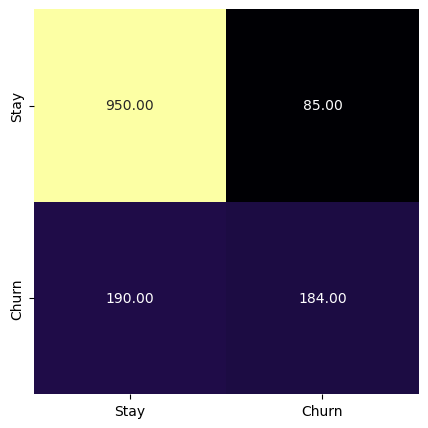


        Precision: 0.6840148698884758
        Recall: 0.4919786096256685
        Specificity: 0.9178743961352657
        Accuracy: 0.8048261178140526
        F1 Score: 0.5723172628304821
        


In [17]:
show_matrix(cm_rf)
show_results(cm_rf)

**Insights:**
1. **Business Impact (Confusion Matrix for Churn):**
    * **Caught Churners (True Positive):** The model successfully identified 182 customers who actually churned.
    * **Missed Churners (False Negative):** The model failed to identify 192 customers who churned.
    * **False Alarms (False Positive):** The model incorrectly flagged 90 loyal customers as churners. This is the potential cost of unnecessary discounts.
2. **Key Churn Metrics:**
   * **Recall:** Out of all actual churners model successfully detected 48.66%
   * **Precision:** When the model rings the alarm and predicts a churn, it is correct 66.91% of the time.
   * **F1 Score:** The overall effectiveness of this model at handling the minority Churn class is 56.35%.

## 5.2 Handling Class Imbalance (F1-Score Optimization)

In [18]:
pipe_rf_f = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=7))
])
param_grid_rf_f = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 5, 10, 15],
    'rf__min_samples_leaf': [1, 2, 4, 5],
    'rf__class_weight': ['balanced']
}
grid_search_rf_f = GridSearchCV(estimator=pipe_rf_f,
                           param_grid = param_grid_rf_f,
                           cv=kfold,
                            scoring='f1', 
                           n_jobs=-1,
                           verbose=1)
grid_search_rf_f.fit(X_train , y_train)
print('The best parameters:', grid_search_rf_f.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
The best parameters: {'rf__class_weight': 'balanced', 'rf__max_depth': None, 'rf__min_samples_leaf': 5, 'rf__n_estimators': 100}


In [19]:
best_model_rf_f = grid_search_rf_f.best_estimator_
y_pred_rf_f = best_model_rf_f.predict(X_test)
y_prob_rf_f = best_model_rf_f.predict_proba(X_test)[:,1]
roc_auc_rf_f = roc_auc_score(y_test, y_prob_rf_f)
cm_rf_f = confusion_matrix(y_test, y_pred_rf_f)

### 5.2.1 Model Results

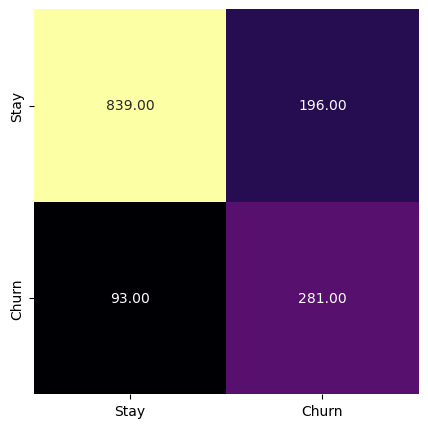


        Precision: 0.589098532494759
        Recall: 0.7513368983957219
        Specificity: 0.8106280193236715
        Accuracy: 0.794889992902768
        F1 Score: 0.6603995299647474
        
ROC-AUC: 0.857487922705314


In [20]:
show_matrix(cm_rf_f)
show_results(cm_rf_f)
print(f"ROC-AUC: {roc_auc_rf_f}")

**Insights:**
1. **Business Impact (Confusion Matrix for Churn):**
    * **Caught Churners (True Positive):** The model successfully identified 281 customers who actually churned.
    * **Missed Churners (False Negative):** The model failed to identify 93 customers who churned.
    * **False Alarms (False Positive):** The model incorrectly flagged 196 loyal customers as churners. This is the potential cost of unnecessary discounts.
2. **Key Churn Metrics:**
   * **Recall:** Out of all actual churners model successfully detected 75.13%
   * **Precision:** When the model rings the alarm and predicts a churn, it is correct 58.91% of the time.
   * **F1 Score:** The overall effectiveness of this model at handling the minority Churn class is 66.04%.
   * **ROC-AUC:** The model's ability to distinguish between churners and loyal customers is 85.57% indicating a very good discriminative performance.

**Conclusion:**

This optimized model significantly improved Recall compared to baseline (48.66% vs 75.13%), dropping the number of missed churners from 192 to just 93. The drop in Precision is an expected consequence of `class_weight='balanced'`, which intentionally penalizes missed churners more heavily. Given that the cost of losing a customer typically exceeds the cost of an unnecessary discount, this trade-off is acceptable.

### 5.2.2 Feature Importance

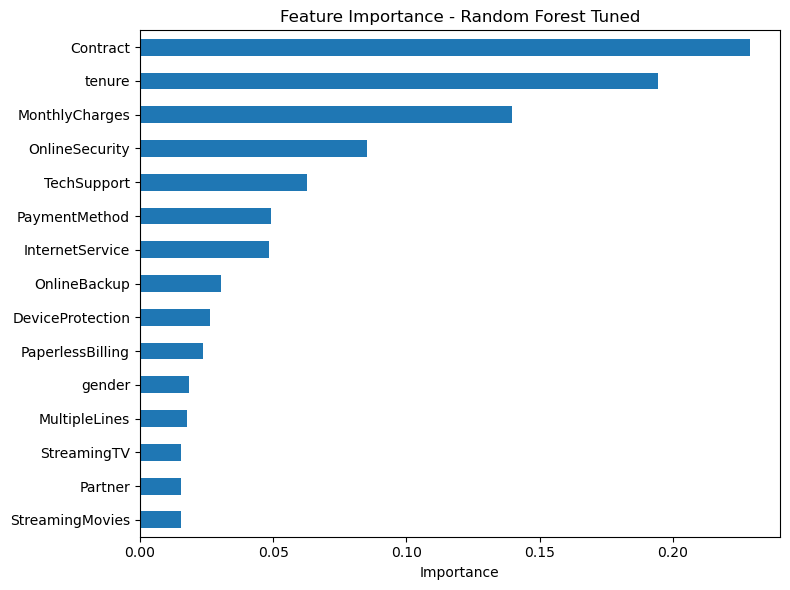

In [21]:
feature_importance(best_model_rf_f, X_train.columns, 'Random Forest Tuned')

**Insights:**

The three most influential features are Contract (~ 0.23), tenure (~ 0.18) and MonthlyCharges (~ 0.15).

# 6. XGBClassifier

## 6.1 First Model (Default settings)

In [22]:
model_xgb = make_pipeline(StandardScaler(), XGBClassifier())
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

### 6.1.1 Model Results

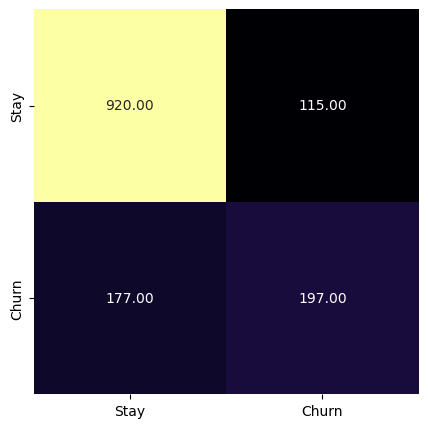


        Precision: 0.6314102564102564
        Recall: 0.5267379679144385
        Specificity: 0.8888888888888888
        Accuracy: 0.7927608232789212
        F1 Score: 0.5743440233236151
        


In [23]:
show_matrix(cm_xgb)
show_results(cm_xgb)

**Insights:**
1. **Business Impact (Confusion Matrix for Churn):**
    * **Caught Churners (True Positive):** The model successfully identified 197 customers who actually churned.
    * **Missed Churners (False Negative):** The model failed to identify 177 customers who churned.
    * **False Alarms (False Positive):** The model incorrectly flagged 115 loyal customers as churners. This is the potential cost of unnecessary discounts.
2. **Key Churn Metrics:**
   * **Recall:** Out of all actual churners model successfully detected 52.67%
   * **Precision:** When the model rings the alarm and predicts a churn, it is correct 63.14% of the time.
   * **F1 Score:** The overall effectiveness of this model at handling the minority Churn class is 57.43%.

## 6.2 Handling Class Imbalance (F1-Score Optimization)

In [24]:
pipe_xgb_f = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(random_state=7, eval_metric='logloss'))
])
param_grid_xgb_f = {
    'xgb__n_estimators': [50,100,200],
    'xgb__max_depth': [3,5,7],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__scale_pos_weight': [2.7 ,2.8]
}
grid_search_xgb_f = GridSearchCV(estimator=pipe_xgb_f,
                           param_grid = param_grid_xgb_f,
                           cv=kfold,
                            scoring='f1', 
                           n_jobs=-1,
                           verbose=1)
grid_search_xgb_f.fit(X_train , y_train)
print('The best parameters:', grid_search_xgb_f.best_params_)
    

Fitting 5 folds for each of 54 candidates, totalling 270 fits
The best parameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__scale_pos_weight': 2.7}


In [25]:
best_model_xgb_f = grid_search_xgb_f.best_estimator_
y_pred_xgb_f = best_model_xgb_f.predict(X_test)
y_prob_xgb_f = best_model_xgb_f.predict_proba(X_test)[:,1]
roc_auc_xgb_f = roc_auc_score(y_test, y_prob_xgb_f)
cm_xgb_f = confusion_matrix(y_test, y_pred_xgb_f)

### 6.2.1 Model Results

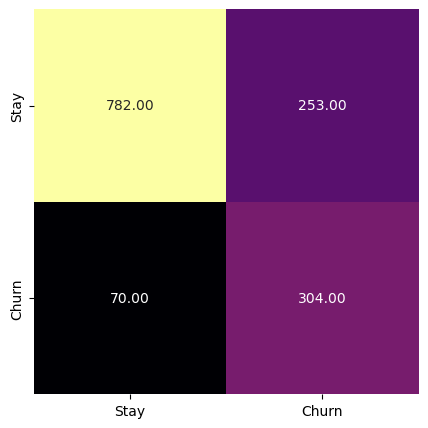


        Precision: 0.5457809694793537
        Recall: 0.8128342245989305
        Specificity: 0.7555555555555555
        Accuracy: 0.7707594038325053
        F1 Score: 0.653061224489796
        
ROC-AUC: 0.8626934304683666


In [26]:
show_matrix(cm_xgb_f)
show_results(cm_xgb_f)
print(f"ROC-AUC: {roc_auc_xgb_f}")

**Insights:**
1. **Business Impact (Confusion Matrix for Churn):**
    * **Caught Churners (True Positive):** The model successfully identified 304 customers who actually churned.
    * **Missed Churners (False Negative):** The model failed to identify 70 customers who churned.
    * **False Alarms (False Positive):** The model incorrectly flagged 253 loyal customers as churners. This is the potential cost of unnecessary discounts.
2. **Key Churn Metrics:**
   * **Recall:** Out of all actual churners model successfully detected 81.28%
   * **Precision:** When the model rings the alarm and predicts a churn, it is correct 54.58% of the time.
   * **F1 Score:** The overall effectiveness of this model at handling the minority Churn class is 65.31%.
   * **ROC-AUC:** The model's ability to distinguish between churners and loyal customers is 86.27% indicating a very good discriminative performance.

**Conclusion:**

This optimized model significantly improved Recall compared to baseline (52.67% vs 81.28%), dropping the number of missed churners from 177 to just 70.The drop in Precision is an expected consequence of `scale_pos_weight`, which intentionally penalizes missed churners more heavily. Given that the cost of losing a customer typically exceeds the cost of an unnecessary discount, this trade-off is acceptable.

### 6.2.2 Feature Importance

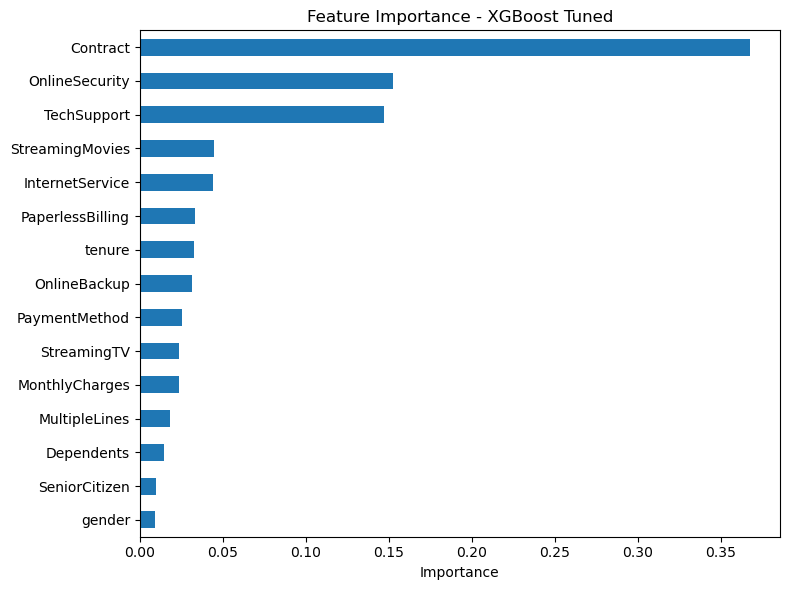

In [27]:
feature_importance(best_model_xgb_f, X_train.columns, 'XGBoost Tuned')

**Insights:**

The three most influential features are Contract (~ 0.37), OnlineSecurity (~ 0.16) and TechSupport (~ 0.15).

# 7. Model Comparison

## 7.1 Results Summary

The table below summarizes the performance of all models.

|Model|Precision|Recall|Specificity|Accuracy|F1|ROC-AUC|FN|
|:-----|:------|:------|:--------|:-------|:------|:-----|:-----|
|LR Default|67.23 %|55.08 %|90.34 %|80.98 %|60.59 %|-|168|
|LR Tuned|54.12 %|82.26 %|74.69 %|76.79 %|65.40 %|85.43 %|65|
|RF Default|66.91 %|48.66 %|91.30%|79.99%|56.35 %|-|192|
|RF Tuned|58.91 %|75.13 %|81.06 %|79.49 %|66.04 %|85.57 %|93|
|XGB Default|63.14 %|52.67 %|88.89 %|79.28 %|57.43 %|-|177|
|XGB Tuned|54.58 %|81.28 %|75.56 %|77.08 %|65.31 %|86.27 %|70|

## 7.2 ROC Curve

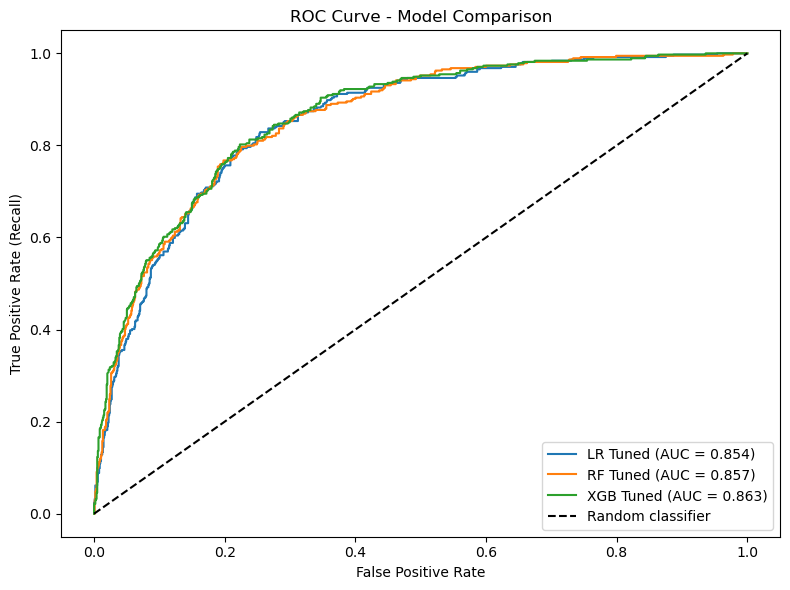

In [31]:
models = {
    'LR Tuned': (best_model_log_f, 'tuned'),
    'RF Tuned': (best_model_rf_f, 'tuned'),
    'XGB Tuned': (best_model_xgb_f, 'tuned')
}

plt.figure(figsize=(8,6))
for name, (model, _) in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
    

**Insights:**

The ROC curves for all three tuned models are nearly identical, with AUC scores ranging from 0.845 (LR Tuned) to 0.863 (XGB Tuned). This indicates that all models have comparable discriminative ability and no single model demonstrates a clear advantage in terms of ROC-AUC. 

## 7.3 Feature Importance Comparison

In [44]:
coefs = best_model_log_f.named_steps['log_reg'].coef_[0]
fi_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefs
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)
fi_lr

,Feature,Coefficient
0,MonthlyCharges,0.825482
1,PaperlessBilling,0.179690
2,InternetService,0.167518
3,SeniorCitizen,0.074650
4,PaymentMethod,0.056067
5,MultipleLines,0.038012
6,StreamingTV,0.021801
7,StreamingMovies,0.017806
8,gender,0.013423
9,Partner,-0.017067


In [42]:
importances_rf = best_model_rf_f.named_steps['rf'].feature_importances_
fi_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances_rf
}).sort_values('Importance', ascending=False).reset_index(drop=True)
fi_rf


,Feature,Importance
0,Contract,0.228665
1,tenure,0.194207
2,MonthlyCharges,0.139443
3,OnlineSecurity,0.085080
4,TechSupport,0.062614
5,PaymentMethod,0.049091
6,InternetService,0.048306
7,OnlineBackup,0.030345
8,DeviceProtection,0.026400
9,PaperlessBilling,0.023782


In [43]:
importances_xgb = best_model_xgb_f.named_steps['xgb'].feature_importances_
fi_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances_xgb
}).sort_values('Importance', ascending=False).reset_index(drop=True)
fi_xgb

,Feature,Importance
0,Contract,0.367392
1,OnlineSecurity,0.152823
2,TechSupport,0.147030
3,StreamingMovies,0.044470
4,InternetService,0.044327
5,PaperlessBilling,0.033530
6,tenure,0.032452
7,OnlineBackup,0.031613
8,PaymentMethod,0.025415
9,StreamingTV,0.023799


**Insights:**
1. **Logistic Regression Tuned** MonthlyCharges has the largest positive coefficient (~ 0.83), indicating that higher monthly bills significantly increase the probability of churn, tenure has the largest negative coefficient (~ -0.76), meaning that longer-tneured customers are significantly less likely to leave. Contract (coef =~ -0.61) as established during EDA customers on month-to-month contracts are most likely to churn. These findings are consistent with the conclusion draw during EDA.
2. **Random Forest Classifier Tuned** The three most influential features are Contract (~ 0.23), tenure (~ 0.18) and MonthlyCharges (~ 0.15), consistent with LR findings.
3. **XGBClassifier Tuned** The three most influential features are Contract (~ 0.37), OnlineSecurity (~ 0.16) and TechSupport (~ 0.15). Notably, XGBoost uniquely highlights the importance of additional services, suggesting that customers without security and support packages are more prone to churn.

All three models consistently identify Contract as the most important churn predictor. Both LR and RF agree on the same top 3 features: Contract, tenure and MonthlyCharges. XGBoost however captures a diffrent pattern - highlighting OnlineSecurity and TechSupport as key drivers suggesting that customers without additional service packages are more prone to churn. These differences reflect each model's approach to learning patterns in the data.



## 7.4 Final Conclusion 

Based on the results, Logistic Regression Tuned is selected as the final model. The primary objective of this project is to identify customers at risk of churning making Recall the most critical metric. LR Tuned achieves the highest Recall (82.26 %) and the lowest number of missed churners (FN=65) meaning only 65 customers who actually left were not flagged by the model.
While Random Forest Tuned achieves a marginally higher F1 Score (66.04 % vs 65.40 %) and Precission (58.61 % vs 54.12 %), these differences are negliglible. Given that LR Tuned outperforms on the most business-critical metric, there is no justification for choosing a more complex model for a marginal gain in secondary metrics. Additionally, Logistic Regression offers a signigicant practical advantage it is interpretable, fast to train and easy to deploy in a production environment.